# Alzheimer's Disease Detection with LeNet-5

This notebook follows the exact same pipeline as the ResNet50 notebook.
Key differences (LeNet-specific):

- No pretrained weights — trained from scratch
- IMG_SIZE reduced to (64, 64): LeNet works well at lower resolution
- Standard /255 pixel normalisation (no ImageNet mean-subtraction)
- LeNet-5 architecture: Conv→Pool→Conv→Pool→Conv→Dense→Dense
- Modern variant: ReLU activations, MaxPool, BatchNorm, Dropout for stability
- class weights for imbalance
- patient-level train/validation/test splits (zero leakage)
- sparse-label training path
- full eval suite: accuracy/loss curves, confusion matrix, ROC-AUC, Scott's Pi


In [10]:
# CHANGES vs ResNet version:
#   - Removed: ResNet50, preprocess_input (no pretrained weights)
#   - IMG_SIZE: (128,128) → (64,64) — LeNet doesn't need large resolution
#   - Normalisation: preprocess_input → /255.0
#   - No transfer learning

import os
import re
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from scipy.stats import skew

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc,
)

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from matplotlib.colors import LogNorm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Config
DATA_ROOT    = "/kaggle/input/datasets/ninadaithal/imagesoasis"
DATASET_DIR = os.path.join(DATA_ROOT, "Data")
IMG_SIZE    = (64, 64)   # CHANGED: was (128,128) — LeNet works well at 64x64, no pretrained weights
BATCH_SIZE  = 32
NUM_CLASSES = 3

CLASS_LABELS = ['Non Demented', 'Very Mild Dementia', 'Mild/Moderate Dementia']
LABEL_MAP = {
    'Non Demented':       0,
    'Very mild Dementia': 1,
    'Mild Dementia':      2,
    'Moderate Dementia':  2,
}

AUTOTUNE = tf.data.AUTOTUNE
print("Imports and configuration ready.")

Imports and configuration ready.


## 1) Collect image paths and build a reference dataframe

In [11]:
def get_info_from_filename(filename: str):
    pattern = re.compile(r'OAS1_(\d+)_MR(\d+)_mpr-(\d+)_(\d+)\.jpg$')
    match = pattern.match(filename)
    if match is None:
        return None
    patient_id, mr_id, scan_id, layer_id = match.groups()
    return int(patient_id), int(mr_id), int(scan_id), int(layer_id)

def create_ref_df(dataset_path: str) -> pd.DataFrame:
    paths, labels = [], []
    patient_ids, mr_ids, scan_ids, layer_ids = [], [], [], []

    for folder in sorted(os.listdir(dataset_path)):
        folder_path = os.path.join(dataset_path, folder)
        if not os.path.isdir(folder_path):
            continue
        for file in sorted(os.listdir(folder_path)):
            parsed = get_info_from_filename(file)
            if parsed is None:
                continue
            patient_id, mr_id, scan_id, layer_id = parsed
            paths.append(os.path.join(folder_path, file))
            labels.append(folder)
            patient_ids.append(patient_id)
            mr_ids.append(mr_id)
            scan_ids.append(scan_id)
            layer_ids.append(layer_id)

    return pd.DataFrame({
        'path':       paths,
        'label':      labels,
        'patient_id': patient_ids,
        'mr_id':      mr_ids,
        'scan_id':    scan_ids,
        'layer_id':   layer_ids,
    })

ref_df = create_ref_df(DATASET_DIR)
print("Shape:", ref_df.shape)
display(ref_df.head())
print(ref_df['label'].value_counts())

Shape: (86437, 6)


,path,label,patient_id,mr_id,scan_id,layer_id
0,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,28,1,1,100
1,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,28,1,1,101
2,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,28,1,1,102
3,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,28,1,1,103
4,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,28,1,1,104


label
Non Demented          67222
Very mild Dementia    13725
Mild Dementia          5002
Moderate Dementia       488
Name: count, dtype: int64


## 2) Quick visual check

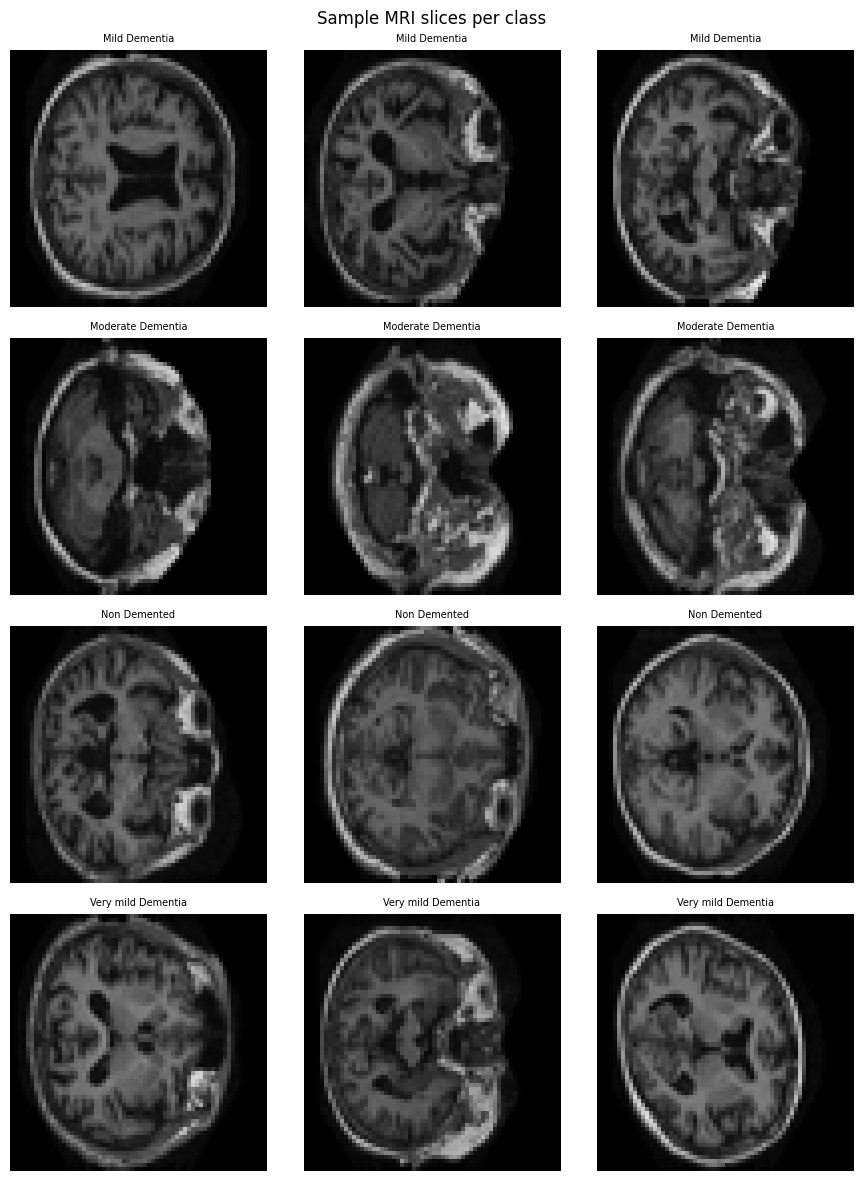

In [12]:
def show_samples(df, n=3, seed=42):
    fig, axes = plt.subplots(len(LABEL_MAP), n, figsize=(n * 3, len(LABEL_MAP) * 3))
    for ax_row, (lbl, grp) in zip(axes, df.groupby('label')):
        sample = grp.sample(n=min(n, len(grp)), random_state=seed)
        for ax, (_, row) in zip(ax_row, sample.iterrows()):
            img = Image.open(row['path']).convert('RGB').resize(IMG_SIZE)
            ax.imshow(img)
            ax.set_title(row['label'], fontsize=7)
            ax.axis('off')
    plt.suptitle('Sample MRI slices per class', fontsize=12)
    plt.tight_layout()
    plt.show()

show_samples(ref_df)

## 3) EDA

In [13]:
ref_df['numeric_label'] = ref_df['label'].map(LABEL_MAP)

print("=== Raw label distribution ===")
print(ref_df['label'].value_counts())
print("\n=== Merged 3-class distribution ===")
print(ref_df['numeric_label'].value_counts().sort_index())
print("\n=== Unique patients per class ===")
print(ref_df.groupby('label')['patient_id'].nunique())

layer_stats = ref_df.groupby('patient_id')['layer_id'].agg(['min', 'max', 'count'])
print("\n=== Slices per patient (stats) ===")
print(layer_stats.describe().round(2))

skewness = skew(ref_df['numeric_label'])
print(f"\nClass label skewness: {skewness:.4f}")

=== Raw label distribution ===
label
Non Demented          67222
Very mild Dementia    13725
Mild Dementia          5002
Moderate Dementia       488
Name: count, dtype: int64

=== Merged 3-class distribution ===
numeric_label
0    67222
1    13725
2     5490
Name: count, dtype: int64

=== Unique patients per class ===
label
Mild Dementia          21
Moderate Dementia       2
Non Demented          266
Very mild Dementia     58
Name: patient_id, dtype: int64

=== Slices per patient (stats) ===
         min    max  count
count  347.0  347.0  347.0
mean   100.0  160.0  249.1
std      0.0    0.0   62.1
min    100.0  160.0  122.0
25%    100.0  160.0  244.0
50%    100.0  160.0  244.0
75%    100.0  160.0  244.0
max    100.0  160.0  488.0

Class label skewness: 1.8871


## 4) Patient-level train / validation / test split

In [14]:
# Split 1: hold out 20% of patients for test
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
trainval_idx, test_idx = next(gss1.split(ref_df, groups=ref_df['patient_id']))
trainval_df = ref_df.iloc[trainval_idx].reset_index(drop=True)
test_df     = ref_df.iloc[test_idx].reset_index(drop=True)

# Split 2: hold out ~15% of remaining patients for validation
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss2.split(trainval_df, groups=trainval_df['patient_id']))
train_final = trainval_df.iloc[train_idx].reset_index(drop=True)
val_df      = trainval_df.iloc[val_idx].reset_index(drop=True)

print(f"Train:      {len(train_final):>6,} images | {train_final['patient_id'].nunique()} patients")
print(f"Validation: {len(val_df):>6,} images | {val_df['patient_id'].nunique()} patients")
print(f"Test:       {len(test_df):>6,} images | {test_df['patient_id'].nunique()} patients")
print("\nTrain class distribution:")
print(train_final['numeric_label'].value_counts().sort_index())

Train:      57,706 images | 235 patients
Validation: 10,187 images | 42 patients
Test:       18,544 images | 70 patients

Train class distribution:
numeric_label
0    44103
1     9577
2     4026
Name: count, dtype: int64


## 5) Build tf.data pipelines

In [15]:
# CHANGED vs ResNet: /255 normalisation — no ImageNet mean-subtraction (no pretrained weights)
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0   # simple /255, consistent with ANN
    return img, label

def build_dataset(df, shuffle=False):
    paths  = df['path'].values
    labels = df['label'].map(LABEL_MAP).values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_final, shuffle=True)
val_ds   = build_dataset(val_df)
test_ds  = build_dataset(test_df)

print("Datasets built.")
print("Train batches :", len(train_ds))
print("Val batches   :", len(val_ds))
print("Test batches  :", len(test_ds))

Datasets built.
Train batches : 1804
Val batches   : 319
Test batches  : 580


## 6) Class weights

In [16]:
train_labels_arr = train_final['label'].map(LABEL_MAP).values
cw = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=train_labels_arr)
class_weight_dict = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:")
for i, label in enumerate(CLASS_LABELS):
    print(f"  Class {i} ({label}): {class_weight_dict[i]:.4f}")

Class weights:
  Class 0 (Non Demented): 0.4361
  Class 1 (Very Mild Dementia): 2.0085
  Class 2 (Mild/Moderate Dementia): 4.7778


## 7) LeNet-5 model definition

In [17]:
# CHANGED vs ResNet: from-scratch LeNet-5 — no ResNet50, no pretrained weights
# Architecture follows classic LeNet-5 with modern improvements:
#   ReLU instead of tanh, MaxPool instead of AvgPool, BatchNorm, Dropout
#
# Block     | Layer              | Output (64x64 input)
# -----------------------------------------------------------------
# Input     | (64, 64, 3)        |
# C1        | Conv2D(6, 5x5)     | (64, 64, 6)   [same padding]
#           | BatchNorm + ReLU   |
# S2        | MaxPool(2x2)       | (32, 32, 6)
# C3        | Conv2D(16, 5x5)    | (28, 28, 16)  [valid padding]
#           | BatchNorm + ReLU   |
# S4        | MaxPool(2x2)       | (14, 14, 16)
# C5        | Conv2D(120, 5x5)   | (10, 10, 120) [valid padding]
#           | BatchNorm + ReLU   |
# F6        | Flatten → Dense(84)|
#           | Dropout(0.4)       |
# Output    | Dense(3, softmax)  |

def build_lenet(input_shape=(64, 64, 3), num_classes=3):
    inp = layers.Input(shape=input_shape)

    # Block 1 — C1 + S2
    x = layers.Conv2D(6, kernel_size=5, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=2, strides=2)(x)

    # Block 2 — C3 + S4
    x = layers.Conv2D(16, kernel_size=5, padding='valid', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=2, strides=2)(x)

    # Block 3 — C5 (fully connected conv)
    x = layers.Conv2D(120, kernel_size=5, padding='valid', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Classifier
    x = layers.Flatten()(x)
    x = layers.Dense(84, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inp, out, name='LeNet5')

model = build_lenet(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
model.summary()

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 6)      │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 120)    │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 120)    │           480 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │     1,008,084 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,059,899 (4.04 MB)

 Trainable params: 1,059,615 (4.04 MB)

 Non-trainable params: 284 (1.11 KB)

## 8) Compile and train

In [18]:
# CHANGED vs ResNet:
#   lr: 1e-4 (ResNet fine-tuning) → 1.2e-4 (from-scratch, slightly higher)
#   epochs: 20 → 50 (no pretrained weights — needs more epochs)
#   EarlyStopping patience=5 — will stop early if val_loss plateaus
#   ReduceLROnPlateau patience=3 — drops LR sooner to help convergence

model.compile(
    optimizer=Adam(learning_rate=1.2e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,     # CHANGED: 3 (triggers LR drop sooner)
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 62s 11ms/step - accuracy: 0.7685 - loss: 0.5634 - val_accuracy: 0.6994 - val_loss: 1.0778 - learning_rate: 1.2000e-04
Epoch 2/50
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9790 - loss: 0.0560 - val_accuracy: 0.6960 - val_loss: 1.3670 - learning_rate: 1.2000e-04
Epoch 3/50
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9909 - loss: 0.0276 - val_accuracy: 0.7367 - val_loss: 1.4104 - learning_rate: 1.2000e-04
Epoch 4/50
1801/1804 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9929 - loss: 0.0205
Epoch 4: ReduceLROnPlateau reducing learning rate to 5.999999848427251e-05.
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9929 - loss: 0.0205 - val_accuracy: 0.7025 - val_loss: 1.7716 - learning_rate: 1.2000e-04
Epoch 5/50
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9969 - loss: 0.0097 - val_accuracy: 0.7453 - val_loss: 1.5895 - learning_rate: 6.0000e-05
Epoch 6/50
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step -

## KPI 1 & 2 — Training vs Validation Accuracy and Loss Curves

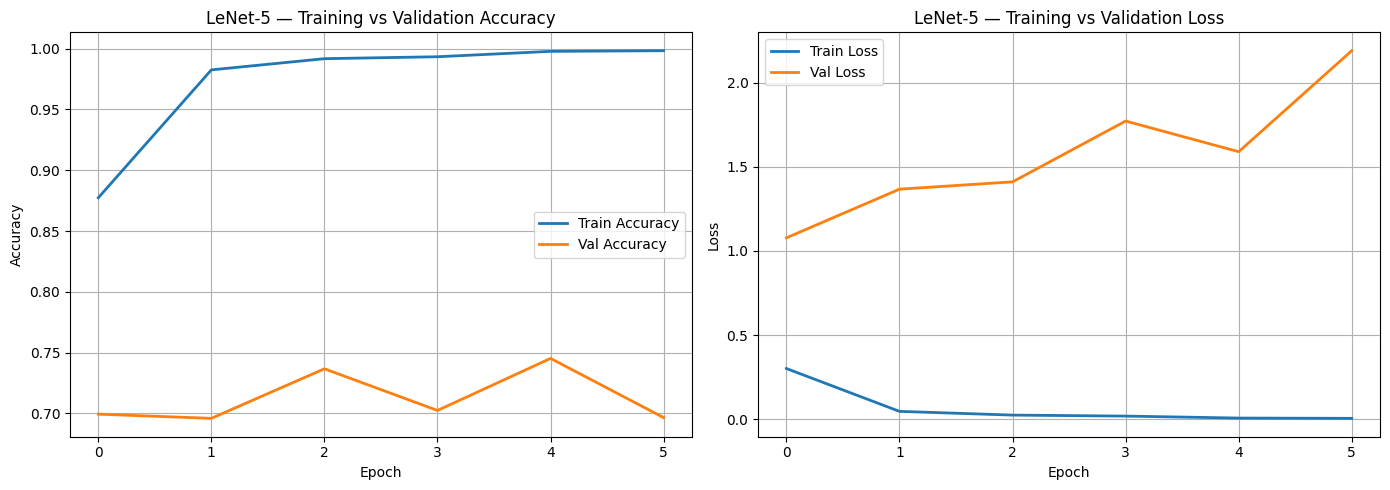

Best val accuracy: 0.7453


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[0].set_title('LeNet-5 — Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss curve
axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[1].set_title('LeNet-5 — Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('lenet_accuracy_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best val accuracy: {max(history.history['val_accuracy']):.4f}")

## 9) Test-set evaluation

In [20]:
y_probs    = model.predict(test_ds, verbose=1)
y_pred     = np.argmax(y_probs, axis=1)
y_test_int = test_df['label'].map(LABEL_MAP).values.astype(np.int32)
y_test_onehot = to_categorical(y_test_int, num_classes=NUM_CLASSES)

print(classification_report(y_test_int, y_pred, target_names=CLASS_LABELS, digits=4))

580/580 ━━━━━━━━━━━━━━━━━━━━ 40s 69ms/step
                        precision    recall  f1-score   support

          Non Demented     0.8956    0.8899    0.8927     15128
    Very Mild Dementia     0.3385    0.4203    0.3750      2196
Mild/Moderate Dementia     0.1747    0.1123    0.1367      1220

              accuracy                         0.7832     18544
             macro avg     0.4696    0.4742    0.4681     18544
          weighted avg     0.7822    0.7832    0.7817     18544



## KPI 3 — Confusion Matrix

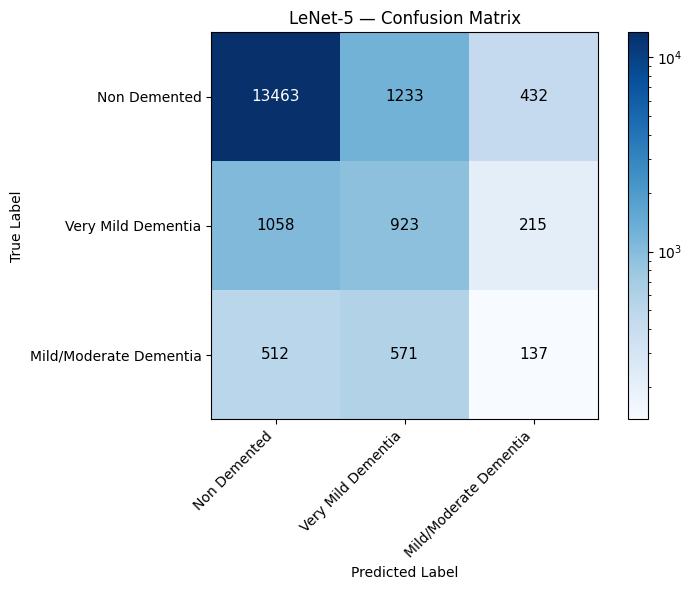

In [21]:
cm = confusion_matrix(y_test_int, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues',
               norm=LogNorm(vmin=max(1, cm.min()), vmax=cm.max()))
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_LABELS, rotation=45, ha='right')
ax.set_yticklabels(CLASS_LABELS)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('LeNet-5 — Confusion Matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=11)
plt.tight_layout()
plt.savefig('lenet_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-class Precision / Recall / F1

In [22]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_int, y_pred, average=None, labels=[0, 1, 2], zero_division=0
)
for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    print(f"Class {i} ({CLASS_LABELS[i]}): Precision={p:.4f}  Recall={r:.4f}  F1={f:.4f}")

micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
    y_test_int, y_pred, average='micro', zero_division=0
)
print(f"Micro-average: Precision={micro_p:.4f}  Recall={micro_r:.4f}  F1={micro_f1:.4f}")

Class 0 (Non Demented): Precision=0.8956  Recall=0.8899  F1=0.8927
Class 1 (Very Mild Dementia): Precision=0.3385  Recall=0.4203  F1=0.3750
Class 2 (Mild/Moderate Dementia): Precision=0.1747  Recall=0.1123  F1=0.1367
Micro-average: Precision=0.7832  Recall=0.7832  F1=0.7832


## KPI 4 — ROC-AUC Curves (one per class)

Class 0 (Non Demented): ROC AUC = 0.8339
Class 1 (Very Mild Dementia): ROC AUC = 0.7855
Class 2 (Mild/Moderate Dementia): ROC AUC = 0.7935
Micro-average ROC AUC: 0.9192


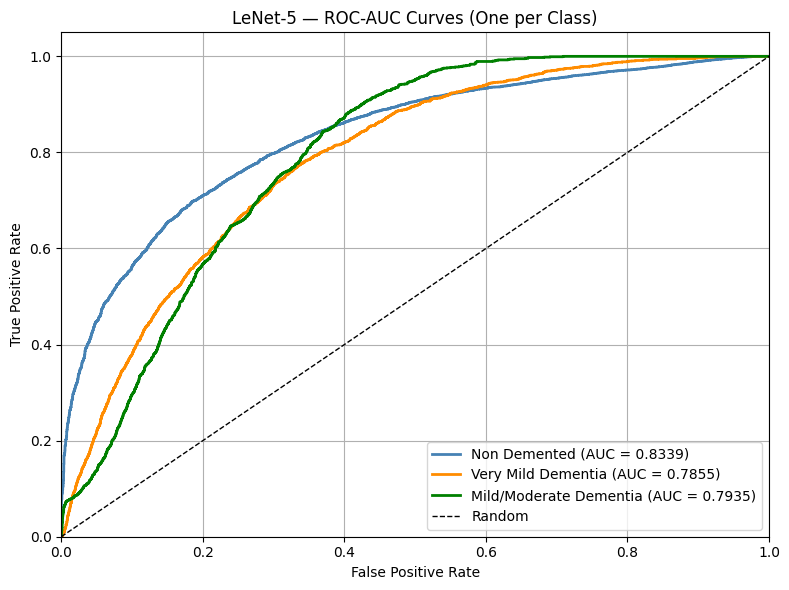

In [23]:
# Scalar AUC scores
try:
    roc_auc_per_class = roc_auc_score(y_test_onehot, y_probs, average=None)
    for i, auc_score in enumerate(np.atleast_1d(roc_auc_per_class)):
        print(f"Class {i} ({CLASS_LABELS[i]}): ROC AUC = {auc_score:.4f}")
    roc_auc_micro = roc_auc_score(y_test_onehot, y_probs, average='micro')
    print("Micro-average ROC AUC:", round(roc_auc_micro, 4))
except ValueError as e:
    print("ROC AUC could not be computed:", e)

# Plot — one curve per class
colors = ['steelblue', 'darkorange', 'green']
fig, ax = plt.subplots(figsize=(8, 6))
for i, (color, label) in enumerate(zip(colors, CLASS_LABELS)):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_probs[:, i])
    roc_auc_i = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc_i:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('LeNet-5 — ROC-AUC Curves (One per Class)')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.savefig('lenet_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()

## Scott's Pi

In [24]:
def scotts_pi(cm):
    total = np.sum(cm)
    if total == 0:
        return np.nan
    p_o        = np.trace(cm) / total
    row_totals = np.sum(cm, axis=1) / total
    col_totals = np.sum(cm, axis=0) / total
    p_e = np.sum(row_totals * col_totals)
    if np.isclose(1 - p_e, 0):
        return np.nan
    return (p_o - p_e) / (1 - p_e)

print("Scott's Pi:", round(scotts_pi(cm), 4))

Scott's Pi: 0.3191


## 9) Leakage and sanity checks

In [25]:
print("Train ∩ Val patient overlap :", len(set(train_final['patient_id']) & set(val_df['patient_id'])))
print("Train ∩ Test patient overlap:", len(set(train_final['patient_id']) & set(test_df['patient_id'])))
print("Val   ∩ Test patient overlap:", len(set(val_df['patient_id'])  & set(test_df['patient_id'])))

print("\nTrain path overlap with test:", len(set(train_final['path']) & set(test_df['path'])))
print("Val path overlap with test  :", len(set(val_df['path'])   & set(test_df['path'])))

Train ∩ Val patient overlap : 0
Train ∩ Test patient overlap: 0
Val   ∩ Test patient overlap: 0

Train path overlap with test: 0
Val path overlap with test  : 0


## 10) Save the trained model

In [26]:
# CHANGED: filename updated to reflect LeNet architecture
model.save("alzheimers_lenet_final.keras")
print("Model saved as alzheimers_lenet_final.keras")

Model saved as alzheimers_lenet_final.keras
